In [2]:
import os
os.chdir('..')
print(os.getcwd())

C:\Users\nbellon\Documents\GitHub\proyecto_aplicado_en_analitica_de_datos


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
# Raíz del proyecto
PROJECT_ROOT = Path().resolve()
# Ruta a la carpeta de datos procesados
path = PROJECT_ROOT / "data" / "raw"
#df = pd.read_csv(path / 'Dataset_Consolidado.csv')
df_precio = pd.read_csv(path / 'US Coffee C Futures Historical Data.csv')

In [4]:
print(f'Shape: {df_precio.shape}')
print(f'\nColumnas: {df_precio.columns.tolist()}')
print(f'\nPrimeras filas:')
print(df_precio.head())
print(f'\nÚltimas filas:')
print(df_precio.tail())
print(f'\nTipos:')
print(df_precio.dtypes)

Shape: (4894, 7)

Columnas: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

Primeras filas:
         Date   Price    Open    High     Low    Vol. Change %
0  05/15/2026  266.90  275.00  278.00  265.55  18.42K   -3.19%
1  05/14/2026  275.70  280.65  280.75  274.50  12.53K   -1.80%
2  05/13/2026  280.75  283.05  286.70  279.35  12.56K    0.21%
3  05/12/2026  280.15  282.00  282.85  275.65  15.49K   -0.76%
4  05/11/2026  282.30  275.70  282.70  268.00  19.33K    2.73%

Últimas filas:
            Date   Price    Open    High    Low    Vol. Change %
4889  01/09/2007  118.40  119.40  120.00  118.0  14.69K   -1.42%
4890  01/08/2007  120.10  120.25  120.90  119.2  10.34K   -0.29%
4891  01/05/2007  120.45  123.25  124.00  119.6  19.08K   -3.64%
4892  01/04/2007  125.00  123.80  125.25  122.6  13.39K    1.13%
4893  01/03/2007  123.60  124.30  125.90  122.4  18.09K   -2.06%

Tipos:
Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vo

Precio promedio anual del café - HISTÓRICO 2007-2025:
      Precio_prom_USc_lb  Precio_prom_USD_ton  Precio_min_USD_ton  Precio_max_USD_ton  n_dias
anio                                                                                         
2007              117.29              2585.85             2234.38             3071.04     249
2008              131.98              2909.57             2239.89             3646.44     253
2009              125.41              2764.78             2282.88             3267.25     253
2010              163.91              3613.62             2815.30             5302.11     260
2011              253.11              5580.12             4650.65             6721.89     258
2012              174.81              3853.95             2943.17             5178.65     253
2013              125.84              2774.36             2237.69             3445.82     253
2014              177.48              3912.71             2438.97             4892.05     254
2015  

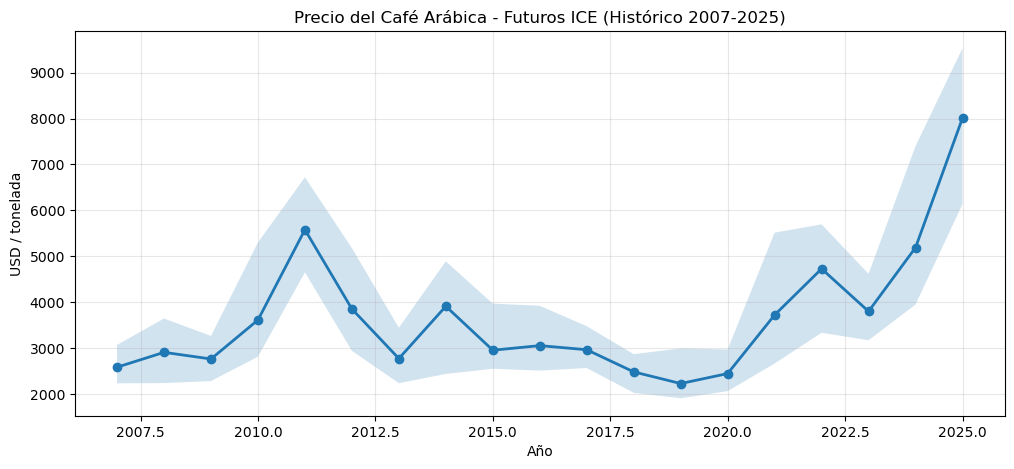

In [5]:
# ── Procesar precios históricos del café (hasta 2025) ─────────

# Parsear fechas (formato MM/DD/YYYY)
df_precio['Date'] = pd.to_datetime(df_precio['Date'], format='%m/%d/%Y')
df_precio = df_precio.sort_values('Date').reset_index(drop=True)

# Price está en centavos USD por libra (USc/lb) - unidad estándar de ICE
# Conversión: 1 tonelada = 2,204.62 libras
LIBRAS_POR_TON = 2204.62

df_precio['Precio_USD_ton'] = (df_precio['Price'] / 100) * LIBRAS_POR_TON
df_precio['anio'] = df_precio['Date'].dt.year

# Filtrar solo histórico: 2007-2025
df_precio_hist = df_precio[df_precio['anio'].between(2007, 2025)].copy()

# Promedio anual histórico
precio_anual_hist = df_precio_hist.groupby('anio').agg(
    Precio_prom_USc_lb=('Price', 'mean'),
    Precio_prom_USD_ton=('Precio_USD_ton', 'mean'),
    Precio_min_USD_ton=('Precio_USD_ton', 'min'),
    Precio_max_USD_ton=('Precio_USD_ton', 'max'),
    n_dias=('Price', 'count')
).round(2)

print('Precio promedio anual del café - HISTÓRICO 2007-2025:')
print(precio_anual_hist.to_string())

plt.figure(figsize=(12, 5))
plt.plot(precio_anual_hist.index, precio_anual_hist['Precio_prom_USD_ton'], 'o-', linewidth=2)
plt.fill_between(precio_anual_hist.index, precio_anual_hist['Precio_min_USD_ton'], 
                 precio_anual_hist['Precio_max_USD_ton'], alpha=0.2)
plt.xlabel('Año')
plt.ylabel('USD / tonelada')
plt.title('Precio del Café Arábica - Futuros ICE (Histórico 2007-2025)')
plt.grid(alpha=0.3)
plt.show()

In [6]:
# PM30 mensual histórico (2007-2025) 

df_hist_sorted = df_precio_hist.sort_values('Date').reset_index(drop=True)

df_hist_sorted['PM30_USc_lb'] = df_hist_sorted['Price'].rolling(window=30, min_periods=15).mean()
df_hist_sorted['PM30_USD_ton'] = (df_hist_sorted['PM30_USc_lb'] / 100) * LIBRAS_POR_TON
df_hist_sorted['anio'] = df_hist_sorted['Date'].dt.year
df_hist_sorted['mes'] = df_hist_sorted['Date'].dt.month

precio_mensual_hist = (
    df_hist_sorted
    .groupby(['anio', 'mes'])
    .agg(
        precio_cierre_USc=('Price', 'last'),
        precio_prom_mes_USc=('Price', 'mean'),
        PM30_cierre_USc=('PM30_USc_lb', 'last'),
        PM30_cierre_USD_ton=('PM30_USD_ton', 'last'),
        n_dias=('Price', 'count')
    )
    .round(2)
    .reset_index()
)
precio_mensual_hist = precio_mensual_hist.dropna(subset=['PM30_cierre_USD_ton'])
precio_mensual_hist['fuente'] = 'Histórico'

print(f'Precio mensual histórico: {precio_mensual_hist.shape[0]} meses')
print(f'Período: {precio_mensual_hist["anio"].min()}/01 a {precio_mensual_hist["anio"].max()}/12')

# Curva forward: contratos futuros 2026-2027
from scipy.interpolate import CubicSpline
from datetime import datetime

contratos = {
    '2026-03': 349.18, '2026-05': 334.49, '2026-07': 326.96,
    '2026-09': 321.27, '2026-12': 314.74,
    '2027-03': 311.60, '2027-05': 307.79, '2027-07': 304.60,
    '2027-09': 300.32, '2027-12': 296.17,
}

fecha_base = datetime(2026, 1, 1)
meses_contratos, precios_contratos = [], []

for fecha_str, precio in contratos.items():
    fecha = datetime.strptime(fecha_str, '%Y-%m')
    meses_desde_base = (fecha.year - fecha_base.year) * 12 + (fecha.month - fecha_base.month)
    meses_contratos.append(meses_desde_base)
    precios_contratos.append(precio)

# Interpolación spline cúbica
cs = CubicSpline(meses_contratos, precios_contratos, bc_type='natural')

# Generar 24 meses: Ene 2026 a Dic 2027
precio_forward = []
for m in range(24):
    anio = 2026 + m // 12
    mes = m % 12 + 1
    precio_usc = float(cs(m))
    precio_usd_ton = (precio_usc / 100) * LIBRAS_POR_TON
    es_observado = m in meses_contratos
    
    precio_forward.append({
        'anio': anio,
        'mes': mes,
        'precio_cierre_USc': round(precio_usc, 2),
        'precio_prom_mes_USc': round(precio_usc, 2),
        'PM30_cierre_USc': round(precio_usc, 2),
        'PM30_cierre_USD_ton': round(precio_usd_ton, 2),
        'n_dias': 0,
        'fuente': 'Contrato' if es_observado else 'Interpolado'
    })

precio_forward_df = pd.DataFrame(precio_forward)

print(f'\nCurva forward interpolada: {precio_forward_df.shape[0]} meses')
print(precio_forward_df[['anio', 'mes', 'PM30_cierre_USc', 'PM30_cierre_USD_ton', 'fuente']].to_string(index=False))

# ── Unificar: histórico + forward 
precio_mensual_full = pd.concat([precio_mensual_hist, precio_forward_df], ignore_index=True)
precio_mensual_full = precio_mensual_full.sort_values(['anio', 'mes']).reset_index(drop=True)

print(f'\nTABLA UNIFICADA')
print(f'Total: {precio_mensual_full.shape[0]} meses ({precio_mensual_full["anio"].min()}-{precio_mensual_full["anio"].max()})')
print(f'  Histórico:    {(precio_mensual_full["fuente"] == "Histórico").sum()} meses')
print(f'  Contrato:     {(precio_mensual_full["fuente"] == "Contrato").sum()} meses')
print(f'  Interpolado:  {(precio_mensual_full["fuente"] == "Interpolado").sum()} meses')

Precio mensual histórico: 228 meses
Período: 2007/01 a 2025/12

Curva forward interpolada: 24 meses
 anio  mes  PM30_cierre_USc  PM30_cierre_USD_ton      fuente
 2026    1           363.87              8021.95 Interpolado
 2026    2           357.20              7874.86 Interpolado
 2026    3           349.18              7698.09    Contrato
 2026    4           341.16              7521.32 Interpolado
 2026    5           334.49              7374.23    Contrato
 2026    6           330.06              7276.55 Interpolado
 2026    7           326.96              7208.23    Contrato
 2026    8           324.08              7144.64 Interpolado
 2026    9           321.27              7082.78    Contrato
 2026   10           318.66              7025.32 Interpolado
 2026   11           316.43              6975.99 Interpolado
 2026   12           314.74              6938.82    Contrato
 2027    1           313.67              6915.19 Interpolado
 2027    2           312.80              6896.

══ PRECIO ANUAL DE REFERENCIA (Histórico + Forward) ══

 anio  PM30_prom_USD_ton  PM30_min_USD_ton  PM30_max_USD_ton  n_meses    fuente
 2007            2581.22           2348.21           2860.09       12 Histórico
 2008            2921.35           2412.63           3271.36       12 Histórico
 2009            2745.33           2431.25           3112.52       12 Histórico
 2010            3572.91           2905.98           4799.22       12 Histórico
 2011            5581.91           4943.32           6182.23       12 Histórico
 2012            3880.00           3140.11           4915.61       12 Histórico
 2013            2786.95           2357.51           3271.95       12 Histórico
 2014            3879.80           2570.28           4422.91       12 Histórico
 2015            2978.48           2685.85           3734.99       12 Histórico
 2016            3046.05           2607.29           3621.20       12 Histórico
 2017            2973.05           2716.79           3305.13    

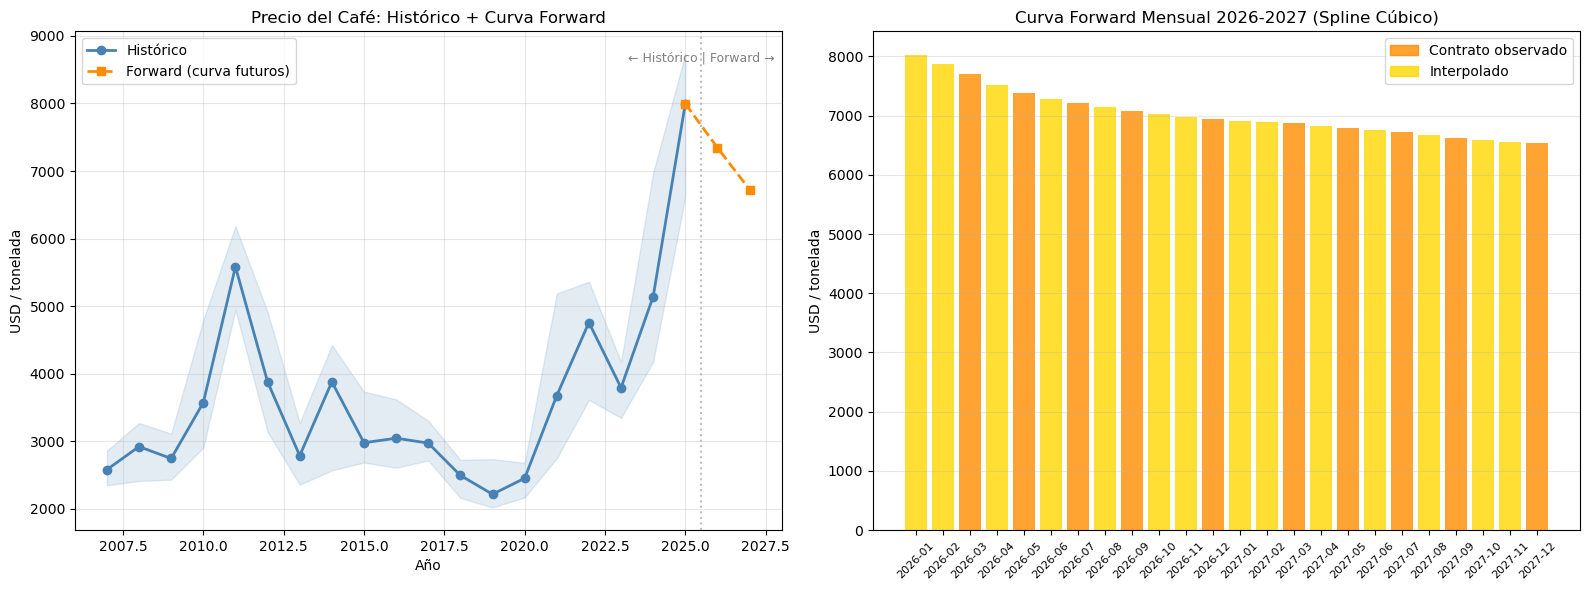

  - precios_cafe_2007-2027.csv (mensual, 252 filas)
  - precios_cafe_anual_2007-2027.csv (anual, 21 filas)


In [7]:
# Tabla anual y guardado final
PATH_MODEL = PROJECT_ROOT / "data" / "model"

# Precio anual (histórico + forward)
precio_anual_final = (
    precio_mensual_full
    .groupby("anio", as_index=False)
    .agg(
        PM30_prom_USD_ton=("PM30_cierre_USD_ton", "mean"),
        PM30_min_USD_ton=("PM30_cierre_USD_ton", "min"),
        PM30_max_USD_ton=("PM30_cierre_USD_ton", "max"),
        n_meses=("mes", "count"),
        fuente=("fuente", "first")
    )
    .round(2)
)

# Corregir columna fuente para años forward
precio_anual_final.loc[precio_anual_final['anio'] >= 2026, 'fuente'] = 'Forward'
precio_anual_final.loc[precio_anual_final['anio'] <= 2025, 'fuente'] = 'Histórico'

print('══ PRECIO ANUAL DE REFERENCIA (Histórico + Forward) ══\n')
print(precio_anual_final.to_string(index=False))

# Visualización: histórico vs forward
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Serie anual completa
hist_mask = precio_anual_final['anio'] <= 2025
fwd_mask = precio_anual_final['anio'] >= 2025

axes[0].plot(precio_anual_final.loc[hist_mask, 'anio'], 
             precio_anual_final.loc[hist_mask, 'PM30_prom_USD_ton'], 
             'o-', color='steelblue', linewidth=2, label='Histórico')
axes[0].plot(precio_anual_final.loc[fwd_mask, 'anio'], 
             precio_anual_final.loc[fwd_mask, 'PM30_prom_USD_ton'], 
             's--', color='darkorange', linewidth=2, label='Forward (curva futuros)')
axes[0].fill_between(precio_anual_final.loc[hist_mask, 'anio'],
                     precio_anual_final.loc[hist_mask, 'PM30_min_USD_ton'],
                     precio_anual_final.loc[hist_mask, 'PM30_max_USD_ton'], alpha=0.15, color='steelblue')
axes[0].axvline(2025.5, color='gray', linestyle=':', alpha=0.5)
axes[0].annotate('← Histórico | Forward →', xy=(2025.5, axes[0].get_ylim()[1]*0.95), 
                 ha='center', fontsize=9, color='gray')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('USD / tonelada')
axes[0].set_title('Precio del Café: Histórico + Curva Forward')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfico 2: Curva forward mensual 2026-2027
fwd_data = precio_mensual_full[precio_mensual_full['anio'] >= 2026].copy()
fwd_data['fecha_label'] = fwd_data.apply(lambda r: f"{int(r['anio'])}-{int(r['mes']):02d}", axis=1)
colors = ['darkorange' if f == 'Contrato' else 'gold' for f in fwd_data['fuente']]

axes[1].bar(range(len(fwd_data)), fwd_data['PM30_cierre_USD_ton'], color=colors, alpha=0.8)
axes[1].set_xticks(range(len(fwd_data)))
axes[1].set_xticklabels(fwd_data['fecha_label'], rotation=45, fontsize=8)
axes[1].set_ylabel('USD / tonelada')
axes[1].set_title('Curva Forward Mensual 2026-2027 (Spline Cúbico)')
axes[1].grid(alpha=0.3, axis='y')

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='darkorange', alpha=0.8, label='Contrato observado'),
    Patch(color='gold', alpha=0.8, label='Interpolado')
])

plt.tight_layout()
plt.show()

# Guardar
precio_mensual_full.to_csv(PATH_MODEL / "precios_cafe_2007-2027.csv", index=False)
precio_anual_final.to_csv(PATH_MODEL / "precios_cafe_anual_2007-2027.csv", index=False)

print(f'  - precios_cafe_2007-2027.csv (mensual, {precio_mensual_full.shape[0]} filas)')
print(f'  - precios_cafe_anual_2007-2027.csv (anual, {precio_anual_final.shape[0]} filas)')